# User Profile Embedding with Temporal Weighting

## Overview
Generate user profile vectors using:
- **weight(p) = exp(-log(2) × days_since_read(p) / half_life)**
- **user_vector = weighted_mean(embeddings, weights)**

This encodes the intuition that recently-read papers better reflect current interests.

## Step 1: Load Data

In [1]:
import pandas as pd
import numpy as np
import json
import scipy.sparse
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt

# ── Load synthetic users ──────────────────────────────────────────────────
with open('UserDataGenerator/synthetic_users.json', 'r') as f:
    data = json.load(f)

# Users are stored in 'train' key
users = data['train']

print(f"✓ Loaded {len(users)} synthetic users")
print(f"  Sample user: {users[0]['user_id']}")
print(f"  - archetype: {users[0]['archetype']}")
print(f"  - history size: {len(users[0]['train_history'])}")

✓ Loaded 1000 synthetic users
  Sample user: user_0001
  - archetype: ML_theorist
  - history size: 42


In [2]:
%pip install nltk scikit-learn scipy joblib -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
# ── Load TF-IDF matrix and preprocessor ───────────────────────────────────
import joblib
from preprocess import TextPreprocessor  # Import to enable unpickling

tfidf_matrix = scipy.sparse.load_npz('arxiv_dataset/tfidf_matrix.npz')
preprocessor = joblib.load('arxiv_dataset/text_preprocessor.pkl')

print(f"✓ Loaded TF-IDF matrix")
print(f"  Shape: {tfidf_matrix.shape}")
print(f"  Format: {type(tfidf_matrix)}")
print(f"  Sparsity: {tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]) * 100:.2f}%")
print(f"\n✓ Loaded Text Preprocessor")
print(f"  Vocabulary size: {len(preprocessor.vectorizer.vocabulary_)}")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\TTD\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\TTD\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\TTD\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\TTD\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\TTD\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


✓ Loaded TF-IDF matrix
  Shape: (136238, 10000)
  Format: <class 'scipy.sparse._csr.csr_matrix'>
  Sparsity: 0.88%

✓ Loaded Text Preprocessor
  Vocabulary size: 10000


In [4]:
# ── Create paper_id → index mapping ──────────────────────────────────────
# Collect all unique paper_ids from users
all_paper_ids = set()
for user in users:
    for paper_id, _ in user['train_history']:
        all_paper_ids.add(paper_id)
    if user['target_paper']:
        all_paper_ids.add(user['target_paper'])
    for neg_paper in user['negative_papers']:
        all_paper_ids.add(neg_paper)

all_paper_ids = sorted(list(all_paper_ids))
n_papers_in_users = len(all_paper_ids)

print(f"✓ Collected {n_papers_in_users} unique paper_ids from {len(users)} users")
print(f"  TFIDF matrix has {tfidf_matrix.shape[0]} papers")
print(f"\n  Sample paper_ids (first 5):")
for i in range(min(5, len(all_paper_ids))):
    print(f"    {all_paper_ids[i]}")

# Create mapping from the exact row order used by the embedding matrix.
# Never sort user paper IDs and treat that position as an embedding row.
paper_df = pd.read_csv('arxiv_dataset/train.csv', usecols=['paper_id'])
if len(paper_df) != tfidf_matrix.shape[0]:
    raise ValueError('train.csv and TF-IDF matrix row counts do not match')
if not paper_df['paper_id'].is_unique:
    raise ValueError('paper_id values in train.csv must be unique')
paper_id_to_idx = {pid: idx for idx, pid in enumerate(paper_df['paper_id'])}
idx_to_paper_id = {idx: pid for pid, idx in paper_id_to_idx.items()}

print(f"\n✓ Created bidirectional paper_id ↔ index mapping")
print(f"  Mapping follows all {len(paper_df)} rows of arxiv_dataset/train.csv")

✓ Collected 26188 unique paper_ids from 1000 users
  TFIDF matrix has 136238 papers

  Sample paper_ids (first 5):
    abs-0704.1394v1
    abs-0704.2083v1
    abs-0705.0214v1
    abs-0705.0828v1
    abs-0705.0952v1

✓ Created bidirectional paper_id ↔ index mapping
  Will use tfidf_matrix[0:26188] for user profile computation


## Step 2: Define Temporal Weighting Function

In [5]:
def compute_temporal_weights(days_ago_list, half_life):
    """
    Compute temporal decay weights for a list of days_ago values.
    
    Formula: weight(p) = exp(-log(2) * days_since_read(p) / half_life)
    
    Args:
        days_ago_list: List of days_ago values
        half_life: Half-life in days (e.g., 30, 60, 90)
    
    Returns:
        weights: Normalized weights (sum to 1)
    """
    days_ago_array = np.array(days_ago_list, dtype=np.float32)
    # Exponential decay: weight = exp(-log(2) * days_ago / half_life)
    weights = np.exp(-np.log(2) * days_ago_array / half_life)
    # Normalize
    weights = weights / weights.sum()
    return weights

# Test the function
test_days = [0, 10, 30, 60, 90]
test_weights_30 = compute_temporal_weights(test_days, half_life=30)
test_weights_60 = compute_temporal_weights(test_days, half_life=60)

print("Test temporal weights:")
print(f"\ndays_ago: {test_days}")
print(f"half_life=30: {test_weights_30}")
print(f"half_life=60: {test_weights_60}")
print(f"\nSum (should be 1.0):")
print(f"  half_life=30: {test_weights_30.sum()}")
print(f"  half_life=60: {test_weights_60.sum()}")

Test temporal weights:

days_ago: [0, 10, 30, 60, 90]
half_life=30: [0.37471421 0.29741086 0.1873571  0.09367855 0.04683928]
half_life=60: [0.28972416 0.25811488 0.20486592 0.14486208 0.10243296]

Sum (should be 1.0):
  half_life=30: 1.0
  half_life=60: 1.0


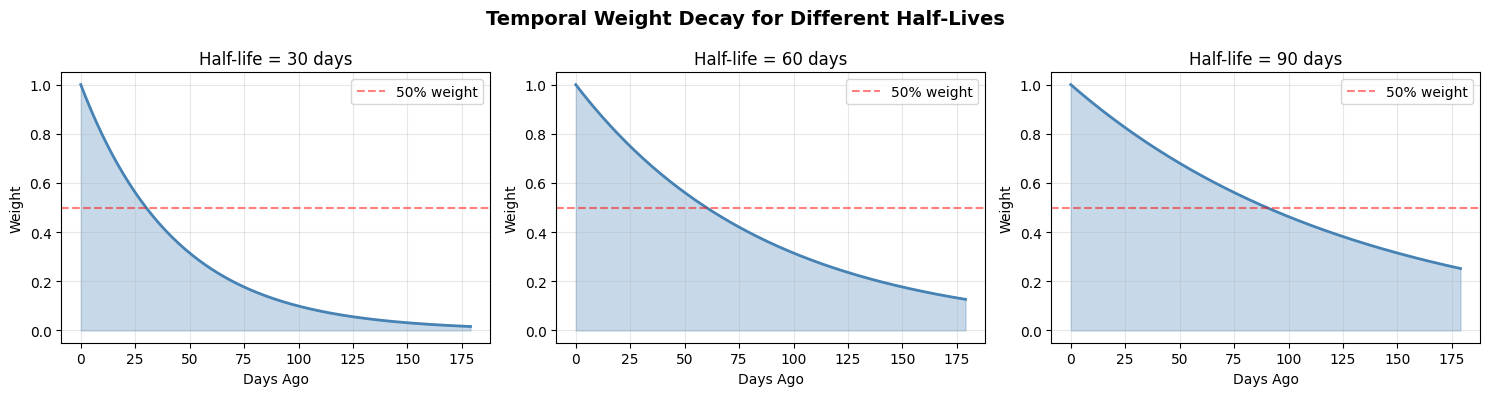

✓ Saved: temporal_weight_decay.png


In [6]:
# Visualize temporal weight decay
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Temporal Weight Decay for Different Half-Lives', fontsize=14, fontweight='bold')

half_lives = [30, 60, 90]
days = np.arange(0, 180, 1)

for idx, half_life in enumerate(half_lives):
    weights = np.exp(-np.log(2) * days / half_life)
    axes[idx].plot(days, weights, linewidth=2, color='steelblue')
    axes[idx].fill_between(days, weights, alpha=0.3, color='steelblue')
    axes[idx].set_title(f'Half-life = {half_life} days')
    axes[idx].set_xlabel('Days Ago')
    axes[idx].set_ylabel('Weight')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50% weight')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('temporal_weight_decay.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: temporal_weight_decay.png")

## Step 3: Generate User Profile Vectors

In [7]:
def compute_user_profile_vector(user, tfidf_matrix, paper_id_to_idx, half_life):
    """
    Compute temporal-weighted user profile vector.
    
    Args:
        user: User dict with 'train_history' field
        tfidf_matrix: Sparse TF-IDF matrix
        paper_id_to_idx: Dict mapping paper_id → index
        half_life: Half-life in days
    
    Returns:
        profile_vector: Dense weighted mean embedding
        metadata: Dict with weighting info
    """
    train_history = user['train_history']
    
    if not train_history:
        return None, {'error': 'Empty history'}
    
    # Extract days_ago and get indices
    days_ago_list = []
    matrix_indices = []
    
    for paper_id, days_ago in train_history:
        if paper_id in paper_id_to_idx:
            days_ago_list.append(days_ago)
            matrix_indices.append(paper_id_to_idx[paper_id])
        else:
            # Paper not found - skip
            pass
    
    if not matrix_indices:
        return None, {'error': 'No valid papers in history'}
    
    # Compute weights
    weights = compute_temporal_weights(days_ago_list, half_life)
    
    # Get embeddings for this user's papers
    embeddings = tfidf_matrix[matrix_indices]  # Shape: (n_papers, n_features)
    
    # Compute weighted mean: sum(weights * embeddings) / sum(weights)
    # Since embeddings is sparse, we need to handle it carefully
    weighted_embeddings = embeddings.multiply(weights[:, np.newaxis])  # Element-wise multiply by weights
    profile_vector = np.asarray(weighted_embeddings.sum(axis=0)).flatten()  # Sum and convert to dense
    
    # Note: weights are already normalized, so this is the weighted mean
    
    metadata = {
        'n_papers': len(matrix_indices),
        'half_life': half_life,
        'weight_min': weights.min(),
        'weight_max': weights.max(),
        'weight_mean': weights.mean(),
    }
    
    return profile_vector, metadata

# Test on first user
test_user = users[0]
test_vector, test_meta = compute_user_profile_vector(test_user, tfidf_matrix, paper_id_to_idx, half_life=30)

if test_vector is not None:
    print(f"✓ Generated profile vector for {test_user['user_id']}")
    print(f"  Vector shape: {test_vector.shape}")
    print(f"  Vector norm: {np.linalg.norm(test_vector):.4f}")
    print(f"  Metadata: {test_meta}")
else:
    print(f"✗ Failed to generate profile: {test_meta}")

✓ Generated profile vector for user_0001
  Vector shape: (10000,)
  Vector norm: 0.2182
  Metadata: {'n_papers': 42, 'half_life': 30, 'weight_min': np.float64(0.014318760100593679), 'weight_max': np.float64(0.03608101451826562), 'weight_mean': np.float64(0.023809523809523808)}


## Step 4: Generate Embeddings for All Users (Multiple Half-Lives)

In [8]:
# Define half-life values to evaluate
half_lives = [30, 60, 90]

# Store results: {half_life: {'vectors': array, 'metadata': list}}
results = {}

for half_life in half_lives:
    print(f"\nGenerating user profiles with half_life={half_life} days...")
    
    vectors_list = []
    metadata_list = []
    failed_users = []
    
    for user_idx, user in enumerate(users):
        profile_vector, metadata = compute_user_profile_vector(
            user, tfidf_matrix, paper_id_to_idx, half_life
        )
        
        if profile_vector is not None:
            vectors_list.append(profile_vector)
            metadata['user_id'] = user['user_id']
            metadata_list.append(metadata)
        else:
            failed_users.append((user['user_id'], metadata))
        
        if (user_idx + 1) % 200 == 0:
            print(f"  Processed {user_idx + 1}/{len(users)} users")
    
    # Stack vectors into matrix
    vectors_matrix = np.vstack(vectors_list)
    
    results[half_life] = {
        'vectors': vectors_matrix,
        'metadata': metadata_list,
        'failed': failed_users,
    }
    
    print(f"✓ Generated {len(vectors_list)} profile vectors")
    print(f"  Matrix shape: {vectors_matrix.shape}")
    print(f"  Failed: {len(failed_users)}")


Generating user profiles with half_life=30 days...
  Processed 200/1000 users
  Processed 400/1000 users
  Processed 600/1000 users
  Processed 800/1000 users
  Processed 1000/1000 users
✓ Generated 1000 profile vectors
  Matrix shape: (1000, 10000)
  Failed: 0

Generating user profiles with half_life=60 days...
  Processed 200/1000 users
  Processed 400/1000 users
  Processed 600/1000 users
  Processed 800/1000 users
  Processed 1000/1000 users
✓ Generated 1000 profile vectors
  Matrix shape: (1000, 10000)
  Failed: 0

Generating user profiles with half_life=90 days...
  Processed 200/1000 users
  Processed 400/1000 users
  Processed 600/1000 users
  Processed 800/1000 users
  Processed 1000/1000 users
✓ Generated 1000 profile vectors
  Matrix shape: (1000, 10000)
  Failed: 0


## Step 5: Analysis and Statistics

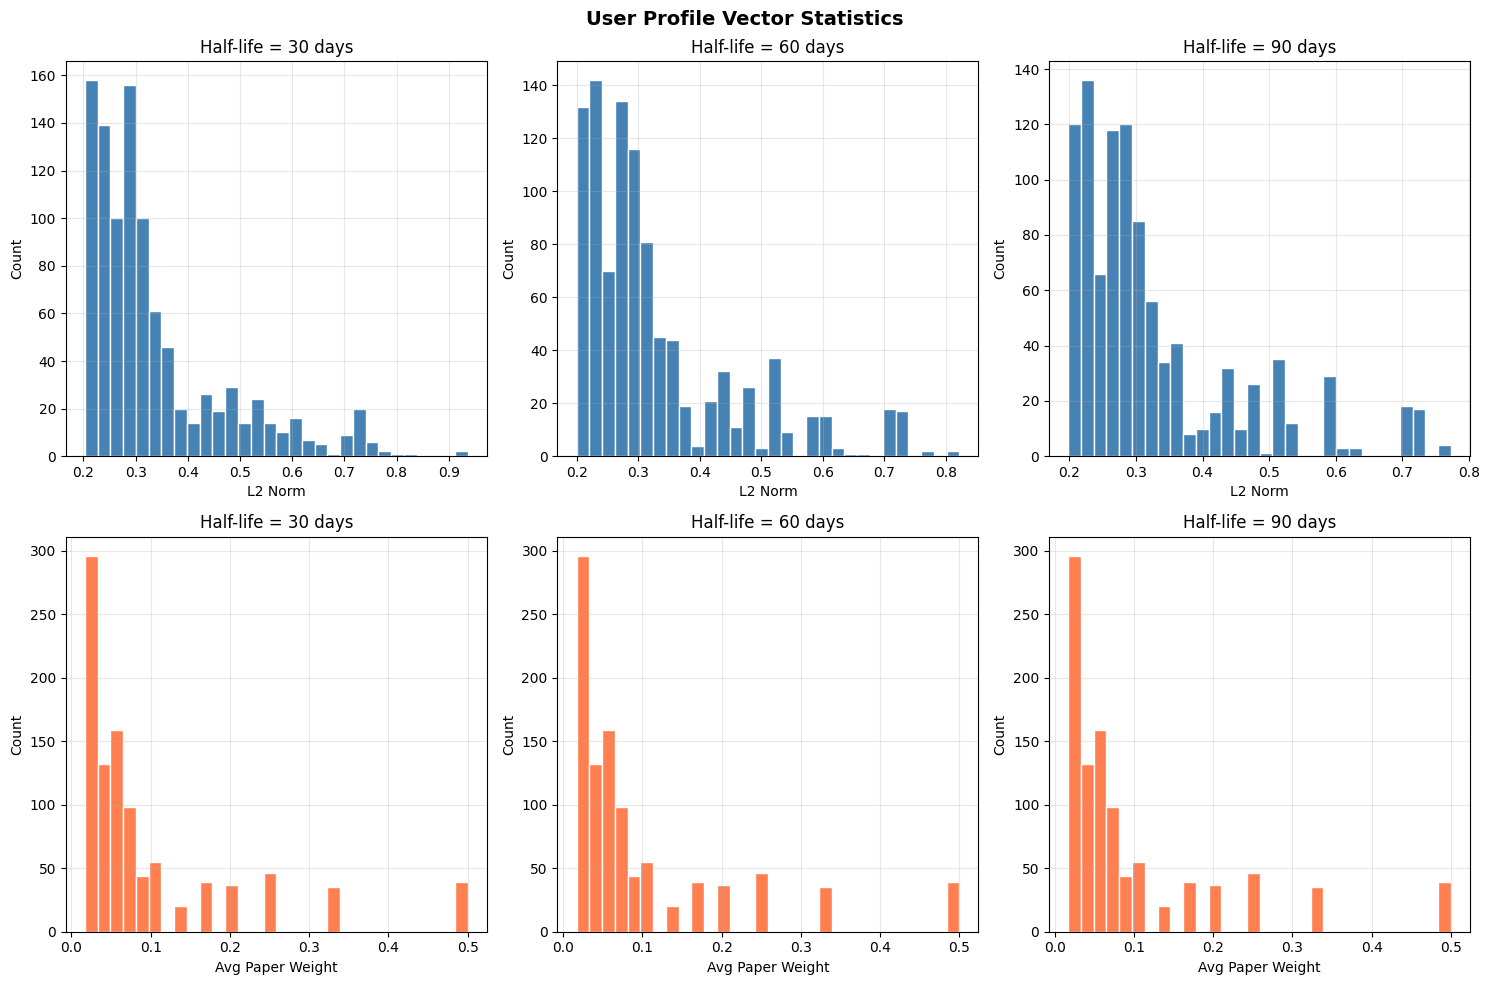

✓ Saved: user_profile_statistics.png


In [9]:
# Compare statistics across half-lives
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('User Profile Vector Statistics', fontsize=14, fontweight='bold')

metrics = ['Vector L2 Norm', 'Vector Mean Abs', 'Average Paper Weight', 'N Papers']

for col, half_life in enumerate(half_lives):
    vectors = results[half_life]['vectors']
    metadata = results[half_life]['metadata']
    
    # Row 0: Vector norms
    vector_norms = np.linalg.norm(vectors, axis=1)
    axes[0, col].hist(vector_norms, bins=30, color='steelblue', edgecolor='white')
    axes[0, col].set_title(f'Half-life = {half_life} days')
    axes[0, col].set_xlabel('L2 Norm')
    axes[0, col].set_ylabel('Count')
    axes[0, col].grid(True, alpha=0.3)
    
    # Row 1: Average paper weights
    weight_means = [m['weight_mean'] for m in metadata]
    axes[1, col].hist(weight_means, bins=30, color='coral', edgecolor='white')
    axes[1, col].set_title(f'Half-life = {half_life} days')
    axes[1, col].set_xlabel('Avg Paper Weight')
    axes[1, col].set_ylabel('Count')
    axes[1, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('user_profile_statistics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: user_profile_statistics.png")

In [10]:
# Detailed statistics summary
print("\n" + "="*70)
print("USER PROFILE EMBEDDING STATISTICS")
print("="*70)

for half_life in half_lives:
    print(f"\n📊 Half-life = {half_life} days")
    print("-" * 70)
    
    vectors = results[half_life]['vectors']
    metadata = results[half_life]['metadata']
    
    # Vector statistics
    vector_norms = np.linalg.norm(vectors, axis=1)
    vector_means = np.mean(np.abs(vectors), axis=1)
    
    print(f"Vector L2 Norm:")
    print(f"  min    : {vector_norms.min():.6f}")
    print(f"  max    : {vector_norms.max():.6f}")
    print(f"  mean   : {vector_norms.mean():.6f}")
    print(f"  median : {np.median(vector_norms):.6f}")
    print(f"  std    : {vector_norms.std():.6f}")
    
    print(f"\nVector Mean Abs Value:")
    print(f"  min    : {vector_means.min():.6f}")
    print(f"  max    : {vector_means.max():.6f}")
    print(f"  mean   : {vector_means.mean():.6f}")
    
    # Weight statistics
    weight_mins = [m['weight_min'] for m in metadata]
    weight_maxs = [m['weight_max'] for m in metadata]
    weight_means = [m['weight_mean'] for m in metadata]
    n_papers = [m['n_papers'] for m in metadata]
    
    print(f"\nPaper Weights (across users):")
    print(f"  min of min    : {min(weight_mins):.6f}")
    print(f"  max of max    : {max(weight_maxs):.6f}")
    print(f"  mean of means : {np.mean(weight_means):.6f}")
    
    print(f"\nNumber of Papers per User:")
    print(f"  min    : {min(n_papers)}")
    print(f"  max    : {max(n_papers)}")
    print(f"  mean   : {np.mean(n_papers):.2f}")
    print(f"  median : {np.median(n_papers):.1f}")


USER PROFILE EMBEDDING STATISTICS

📊 Half-life = 30 days
----------------------------------------------------------------------
Vector L2 Norm:
  min    : 0.202732
  max    : 0.936366
  mean   : 0.336819
  median : 0.290967
  std    : 0.133091

Vector Mean Abs Value:
  min    : 0.000492
  max    : 0.000922
  mean   : 0.000729

Paper Weights (across users):
  min of min    : 0.007420
  max of max    : 0.931557
  mean of means : 0.097522

Number of Papers per User:
  min    : 2
  max    : 59
  mean   : 22.50
  median : 18.0

📊 Half-life = 60 days
----------------------------------------------------------------------
Vector L2 Norm:
  min    : 0.199245
  max    : 0.822045
  mean   : 0.328397
  median : 0.284560
  std    : 0.127696

Vector Mean Abs Value:
  min    : 0.000489
  max    : 0.000922
  mean   : 0.000729

Paper Weights (across users):
  min of min    : 0.011790
  max of max    : 0.786747
  mean of means : 0.097522

Number of Papers per User:
  min    : 2
  max    : 59
  mean   :

## Step 6: Save Results

In [11]:
import os

# Helper function to convert numpy types to Python types for JSON serialization
def convert_to_serializable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.floating, np.integer)):
        return float(obj) if isinstance(obj, np.floating) else int(obj)
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [convert_to_serializable(item) for item in obj]
    return obj

# Create output directory
os.makedirs('user_profiles', exist_ok=True)

for half_life in half_lives:
    vectors = results[half_life]['vectors']
    metadata = results[half_life]['metadata']
    
    # Save vectors as compressed numpy array
    vector_file = f'user_profiles/user_vectors_halflife_{half_life}.npz'
    np.savez_compressed(vector_file, vectors=vectors)
    print(f"✓ Saved: {vector_file}")
    
    # Convert metadata to JSON-serializable format
    metadata_serializable = convert_to_serializable(metadata)
    
    # Save metadata as JSON
    metadata_file = f'user_profiles/user_metadata_halflife_{half_life}.json'
    with open(metadata_file, 'w') as f:
        json.dump(metadata_serializable, f, indent=2)
    print(f"✓ Saved: {metadata_file}")
    
    # Save summary stats
    stats_file = f'user_profiles/summary_stats_halflife_{half_life}.txt'
    with open(stats_file, 'w') as f:
        vector_norms = np.linalg.norm(vectors, axis=1)
        f.write(f"Half-life: {half_life} days\n")
        f.write(f"Number of users: {len(vectors)}\n")
        f.write(f"Vector dimension: {vectors.shape[1]}\n")
        f.write(f"\nVector L2 Norm Statistics:\n")
        f.write(f"  min    : {vector_norms.min():.6f}\n")
        f.write(f"  max    : {vector_norms.max():.6f}\n")
        f.write(f"  mean   : {vector_norms.mean():.6f}\n")
        f.write(f"  median : {np.median(vector_norms):.6f}\n")
        f.write(f"  std    : {vector_norms.std():.6f}\n")
    print(f"✓ Saved: {stats_file}")

✓ Saved: user_profiles/user_vectors_halflife_30.npz
✓ Saved: user_profiles/user_metadata_halflife_30.json
✓ Saved: user_profiles/summary_stats_halflife_30.txt
✓ Saved: user_profiles/user_vectors_halflife_60.npz
✓ Saved: user_profiles/user_metadata_halflife_60.json
✓ Saved: user_profiles/summary_stats_halflife_60.txt
✓ Saved: user_profiles/user_vectors_halflife_90.npz
✓ Saved: user_profiles/user_metadata_halflife_90.json
✓ Saved: user_profiles/summary_stats_halflife_90.txt


In [12]:
# Create a comprehensive summary file
summary = {
    'description': 'Temporal-weighted user profile vectors',
    'formula': 'weight(p) = exp(-log(2) * days_since_read(p) / half_life)',
    'user_vector': 'weighted_mean(embeddings, weights)',
    'half_lives_evaluated': half_lives,
    'total_users': len(users),
    'tfidf_matrix_shape': list(tfidf_matrix.shape),
    'files_generated': {
        '30': {
            'vectors': 'user_profiles/user_vectors_halflife_30.npz',
            'metadata': 'user_profiles/user_metadata_halflife_30.json',
            'stats': 'user_profiles/summary_stats_halflife_30.txt',
        },
        '60': {
            'vectors': 'user_profiles/user_vectors_halflife_60.npz',
            'metadata': 'user_profiles/user_metadata_halflife_60.json',
            'stats': 'user_profiles/summary_stats_halflife_60.txt',
        },
        '90': {
            'vectors': 'user_profiles/user_vectors_halflife_90.npz',
            'metadata': 'user_profiles/user_metadata_halflife_90.json',
            'stats': 'user_profiles/summary_stats_halflife_90.txt',
        },
    },
}

summary_file = 'user_profiles/README.json'
with open(summary_file, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"✓ Saved: {summary_file}")
print("\n" + "="*70)
print("✅ USER PROFILE EMBEDDING GENERATION COMPLETE!")
print("="*70)

✓ Saved: user_profiles/README.json

✅ USER PROFILE EMBEDDING GENERATION COMPLETE!


## Step 7: Example - Load and Use User Profiles

In [13]:
# Example: Load user profiles and compute similarity
from sklearn.metrics.pairwise import cosine_similarity

# Load profiles for half_life=30
half_life = 30
vectors_file = f'user_profiles/user_vectors_halflife_{half_life}.npz'
metadata_file = f'user_profiles/user_metadata_halflife_{half_life}.json'

loaded_data = np.load(vectors_file)
user_vectors = loaded_data['vectors']

with open(metadata_file, 'r') as f:
    loaded_metadata = json.load(f)

print(f"✓ Loaded user vectors (half_life={half_life})")
print(f"  Shape: {user_vectors.shape}")
print(f"  Number of users: {len(loaded_metadata)}")

# Example: Find similar users based on profile vectors
user_a_idx = 0
user_b_idx = 5

similarity = cosine_similarity(
    [user_vectors[user_a_idx]], 
    [user_vectors[user_b_idx]]
)[0][0]

print(f"\nExample: User similarity")
print(f"  User {loaded_metadata[user_a_idx]['user_id']} vs User {loaded_metadata[user_b_idx]['user_id']}")
print(f"  Cosine similarity: {similarity:.4f}")

✓ Loaded user vectors (half_life=30)
  Shape: (1000, 10000)
  Number of users: 1000

Example: User similarity
  User user_0001 vs User user_0701
  Cosine similarity: 0.2927
